# ECS 171 Group Project Team 9

## Introduction

Heart disease is one of the leading causes of death worldwide. Early prediction of heart disease risk can support timely medical intervention and lifestyle changes. The goal of this project is to develop and evaluate machine learning models that predict whether a patient is at risk of heart disease based on clinical and demographic attributes.

This is formulated as a binary classification problem, where the output indicates the presence or absence of heart disease.

## Dataset Description

Dataset: UCI Heart Disease Dataset

Size: ~300 instances
Attributes: ~13 features
Target variable: Presence of heart disease (0 = No, 1 = Yes)

## Exploratory Data Analysis (EDA)

### Data Input

In [ ]:
from ucimlrepo import fetch_ucirepo

heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

print(heart_disease.metadata)
print(heart_disease.variables)

In [ ]:
X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()
X.head()

In [ ]:
y.head()

### Data Cleaning

#### Finding Missing Values and Replace it with NaN

In [ ]:
import numpy as np
import pandas as pd

X = X.replace('?', np.nan)
X.isna().sum()

#### Turning Data Types to Numeric

In [ ]:
num_cols = ['age','trestbps','chol','thalach','oldpeak','ca']
X[num_cols] = X[num_cols].apply(pd.to_numeric)

cat_cols = ['sex','cp','fbs','restecg','exang','slope','thal']
X[cat_cols] = X[cat_cols].apply(pd.to_numeric)

X.info()

#### Turn NaN into numbers

In [ ]:
X['ca'] = X['ca'].fillna(X['ca'].median())
X['thal'] = X['thal'].fillna(X['thal'].mode()[0])

X.isna().sum()

#### Outlier Detection

In [ ]:
def detect_outliers(df, columns):
    outlier_indices = []
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower) | (df[col] > upper)].index
        outlier_indices.extend(outliers)

    return list(set(outlier_indices))


In [ ]:
outlier_cols = ['age','trestbps','chol','thalach','oldpeak']
outliers = detect_outliers(X, outlier_cols)

len(outliers)

#### Cap Outlier

In [ ]:
def cap_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df[col] = np.where(df[col] < lower, lower, df[col])
        df[col] = np.where(df[col] > upper, upper, df[col])
        
    return df

X = cap_outliers(X, outlier_cols)

#### Change Target Value from severity of hear disease to if the patient has heart disease or not

In [ ]:
y = (y['num'] > 0).astype(int)

In [ ]:
y.head()

#### Encode Categorical Variables - One-Hot Encoding

Ex. If a patient has: cp = 3   (non-anginal pain)

it becomes:
cp_2	cp_3	cp_4
0	1	0

Meaning:

The patient is not type 2

The patient is type 3

The patient is not type 4

In [ ]:
X = pd.get_dummies(X, columns=['cp','restecg','slope','thal'], drop_first=True)
X.head()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/heart_disease_clean.csv")

X = df.drop('target', axis=1)
y = df['target']

In [4]:
df.shape

(303, 19)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        303 non-null    int64
 1   sex        303 non-null    int64
 2   trestbps   303 non-null    int64
 3   chol       303 non-null    int64
 4   fbs        303 non-null    int64
 5   thalach    303 non-null    int64
 6   exang      303 non-null    int64
 7   oldpeak    303 non-null    int64
 8   ca         303 non-null    int64
 9   cp_2       303 non-null    int64
 10  cp_3       303 non-null    int64
 11  cp_4       303 non-null    int64
 12  restecg_1  303 non-null    int64
 13  restecg_2  303 non-null    int64
 14  slope_2    303 non-null    int64
 15  slope_3    303 non-null    int64
 16  thal_6.0   303 non-null    int64
 17  thal_7.0   303 non-null    int64
 18  target     303 non-null    int64
dtypes: int64(19)
memory usage: 45.1 KB


In [6]:
df.describe()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_2,cp_3,cp_4,restecg_1,restecg_2,slope_2,slope_3,thal_6.0,thal_7.0,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,131.346535,245.584158,0.148515,149.650165,0.326733,0.755776,0.663366,0.165017,0.283828,0.475248,0.013201,0.488449,0.462046,0.069307,0.059406,0.386139,0.458746
std,9.038662,0.467299,16.648749,47.558803,0.356198,22.738866,0.469794,1.032465,0.934375,0.371809,0.451600,0.500213,0.114325,0.500693,0.499382,0.254395,0.236774,0.487668,0.499120
min,29.000000,0.000000,94.000000,126.000000,0.000000,84.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,120.000000,211.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,130.000000,241.000000,0.000000,153.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,140.000000,275.000000,0.000000,166.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,77.000000,1.000000,170.000000,371.000000,1.000000,202.000000,1.000000,4.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


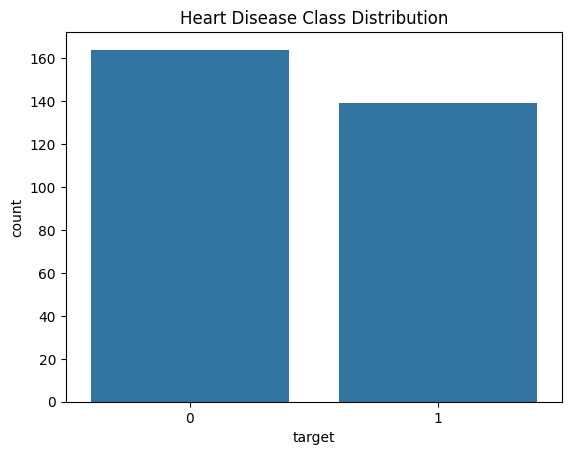

In [7]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Class Distribution")
plt.show()